# 03 — Land-Use Efficiency: Yield vs. Area Change

**Research Question 2:** *Which EU countries achieve higher yields without expanding agricultural land?*

This notebook compares each country's yield change against its area-harvested change between two three-year periods (1995–97 and 2022–24). The result is plotted as a four-quadrant scatter, with the upper-left quadrant,  *higher yield, less land* , identifying the efficiency winners.

### Methodology

- **Three-year averages** for the start (1995–97) and end (2022–24) windows smooth out single-year weather anomalies.
- **Percentage change** rather than absolute change makes countries with very different production scales (France vs. Portugal) comparable.
- **Per-country aggregation** preserves national variation that a regional aggregate would hide.


## 1. Imports and configuration


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

COUNTRY_COLORS = {
    "France":      "#D62828",
    "Germany":     "#1D3557",
    "Italy":       "#1F7A6F",
    "Spain":       "#B8860B",
    "Portugal":    "#6A0572",
    "Netherlands": "#BC4B24",
}


## 2. Load processed data


In [2]:
eu_stat_joined = pd.read_csv(DATA_DIR / "processed" / "eu_stat_joined.csv")
print(f"Shape: {eu_stat_joined.shape}")
eu_stat_joined.head()


Shape: (720, 6)


,Area,Item,Year,production_t,area_ha,Annual Yield (t/ha)
0,France,Grapes,1995,7212900.0,894800.0,8.060907
1,France,Grapes,1996,7716400.0,886690.0,8.702478
2,France,Grapes,1997,7190900.0,878148.0,8.188711
3,France,Grapes,1998,6919069.0,862677.0,8.020463
4,France,Grapes,1999,8040710.0,863355.0,9.313330


## 3. Define the comparison windows

Three-year averaging at each endpoint reduces sensitivity to a single anomalous year (e.g. a drought or frost). The 30-year span (1995→2024) was chosen as the longest fully-covered period in the FAOSTAT extract.


In [3]:
START_YEARS = [1995, 1996, 1997]
END_YEARS = [2022, 2023, 2024]

GROUP_COLS = ["Area", "Item"]
VALUE_COLS = ["area_ha", "Annual Yield (t/ha)"]


## 4. Compute mean values for each window

Group by country and crop, then take the mean across the three years in each window. Because both metrics live in the same dataframe and share the same index after groupby, they can be computed in a single pass per window.


In [4]:
start_means = (
    eu_stat_joined[eu_stat_joined["Year"].isin(START_YEARS)]
    .groupby(GROUP_COLS)[VALUE_COLS]
    .mean()
)

end_means = (
    eu_stat_joined[eu_stat_joined["Year"].isin(END_YEARS)]
    .groupby(GROUP_COLS)[VALUE_COLS]
    .mean()
)

start_means.head()


area_ha  Annual Yield (t/ha)
Area    Item                                           
France  Grapes        8.865460e+05             8.317365
        Maize (corn)  1.720667e+06             8.389637
        Sugar beet    4.562400e+05            69.596675
        Wheat         4.962484e+06             6.757600
Germany Grapes        1.027230e+05            12.640447

## 5. Compute percentage change

Since `start_means` and `end_means` share the same index (country, crop), pandas aligns them automatically — no explicit merge is required. Renaming the columns clarifies what each represents in downstream code.


In [5]:
pct_change = ((end_means - start_means) / start_means) * 100

pct_change = pct_change.rename(columns={
    "area_ha":             "area_pct_change",
    "Annual Yield (t/ha)": "yield_pct_change",
}).reset_index()

pct_change


,Area,Item,area_pct_change,yield_pct_change
0,France,Grapes,-15.318551,-8.524024
1,France,Maize (corn),-15.445774,5.037429
2,France,Sugar beet,-12.780554,13.974962
3,France,Wheat,-3.258805,-0.498522
4,Germany,Grapes,-1.485873,-9.896444
5,Germany,Maize (corn),33.418055,17.819983
6,Germany,Sugar beet,-19.757962,53.946839
7,Germany,Wheat,7.615065,2.895586
8,Italy,Grapes,-20.033003,9.575755
9,Italy,Maize (corn),-48.139153,3.966595


## 6. Visualise the four-quadrant scatter

Each panel is one crop. Each point is one country, plotted with its area-change on the x-axis and yield-change on the y-axis. Four interpretive zones emerge naturally:

| Quadrant | Meaning |
|---|---|
| Upper-left | **Efficiency winners** — higher yield, less land |
| Upper-right | Growth through expansion — higher yield *and* more land |
| Lower-right | Inefficiency — less yield, more land |
| Lower-left | Decline — both shrinking |

### Outlier handling

Dutch grape cultivation expanded by roughly 800% from a tiny base. Plotting this raw value would compress every other point into an unreadable cluster. The x-axis is therefore clipped at ±150% for plotting only — the raw value is retained in the underlying table and would be referenced in any narrative discussion.

### Independent y-axes

`sharey=False` lets each crop's yield-change variation fill its panel. Sugar beet yields shifted by 10–60% while wheat moved only ±10%; sharing the axis would flatten the wheat panel.


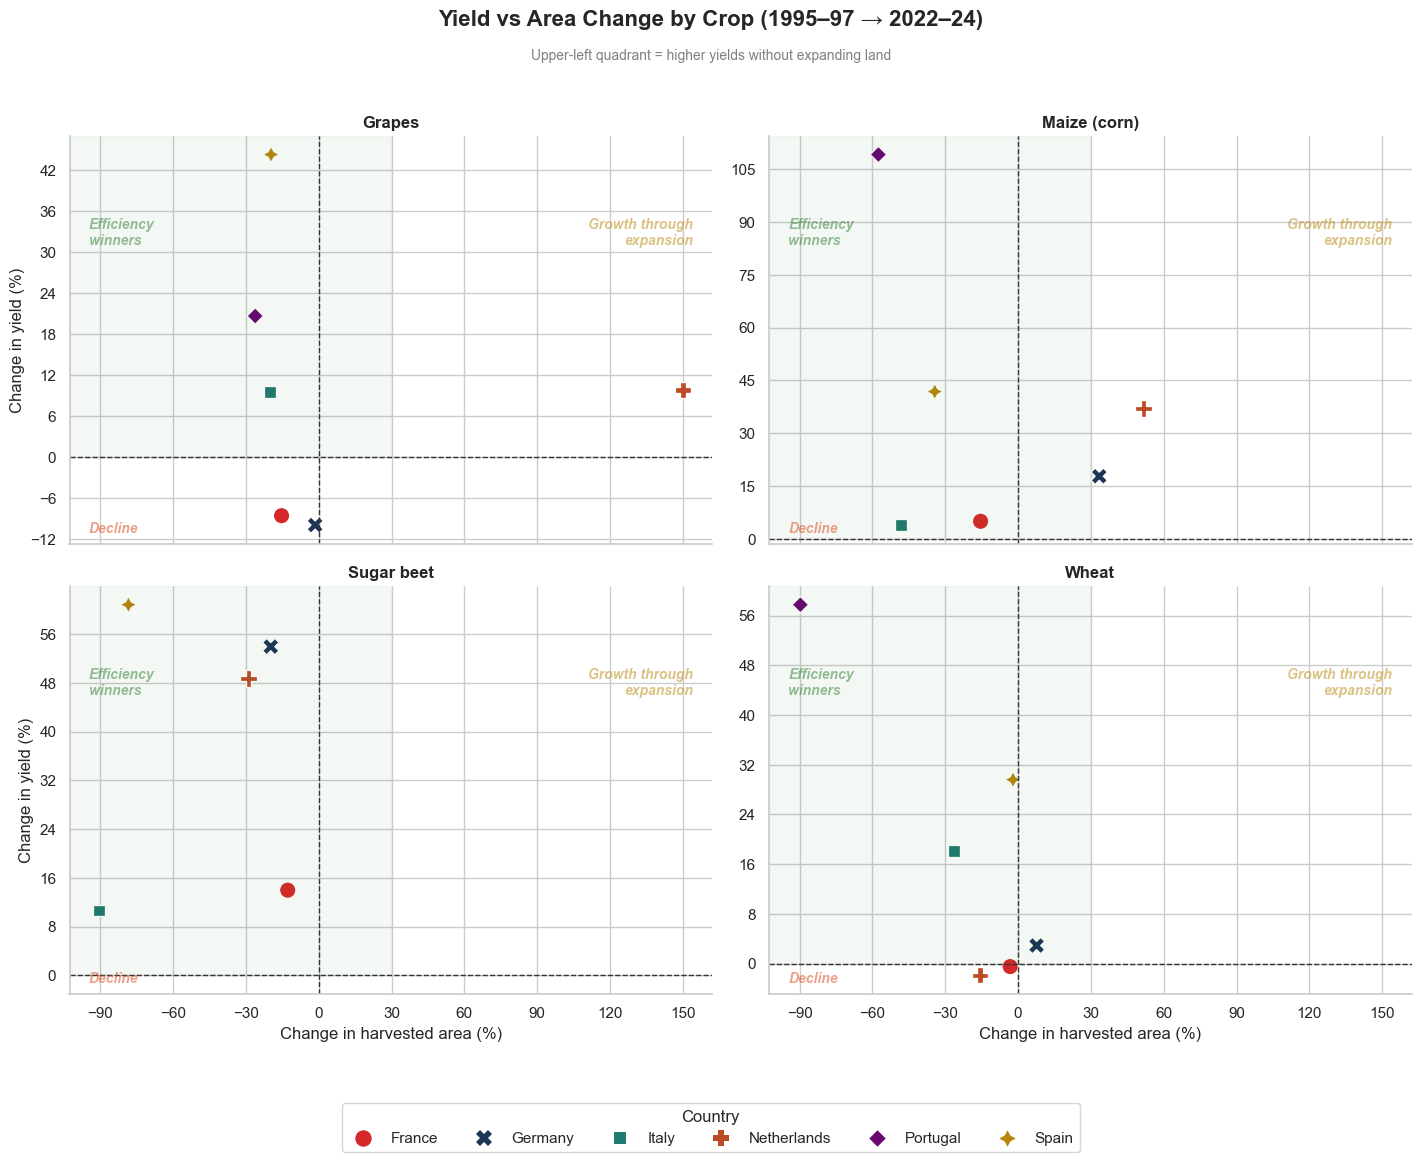

In [6]:
# Cap extreme x-values for plotting
plot_df = pct_change.copy()
X_CAP = 150
plot_df["area_plot"] = plot_df["area_pct_change"].clip(-X_CAP, X_CAP)

g = sns.relplot(
    data=plot_df,
    x="area_plot",
    y="yield_pct_change",
    hue="Area",
    palette=COUNTRY_COLORS,
    style="Area",
    col="Item",
    col_wrap=2,
    kind="scatter",
    s=140,
    height=5,
    aspect=1.3,
    facet_kws={"sharey": False},
)

for ax in g.axes.flat:
    # Reference lines
    ax.axhline(0, color="#333333", linewidth=1, linestyle="--")
    ax.axvline(0, color="#333333", linewidth=1, linestyle="--")

    # Quadrant shading on the upper-left (efficiency winners)
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.axhspan(0, ylim[1], xmin=0, xmax=0.5, color="#2E7D32", alpha=0.05)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Quadrant labels
    ax.text(0.03, 0.80, "Efficiency\nwinners", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color="#2E7D32", alpha=0.5,
            ha="left", va="top", style="italic")
    ax.text(0.97, 0.80, "Growth through\nexpansion", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color="#B8860B", alpha=0.5,
            ha="right", va="top", style="italic")
    ax.text(0.03, 0.02, "Decline", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color="#D84315", alpha=0.5,
            ha="left", va="bottom", style="italic")

    # Integer ticks
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

g.set_axis_labels("Change in harvested area (%)", "Change in yield (%)")
g.set_titles("{col_name}", fontsize=13, fontweight="bold")

g.figure.suptitle(
    "Yield vs Area Change by Crop (1995–97 → 2022–24)",
    fontsize=16, fontweight="bold", y=1.05,
)
g.figure.text(
    0.5, 1.00,
    "Upper-left quadrant = higher yields without expanding land",
    ha="center", fontsize=10, color="gray",
)

sns.move_legend(
    g,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=6,
    title="Country",
    frameon=True,
)

g.figure.tight_layout()
g.figure.savefig(FIGURES_DIR / "yield_vs_area_change_by_crop.png",
                 dpi=400, bbox_inches="tight")
plt.show()


## Summary of findings

**Efficiency winners (upper-left quadrant — higher yields with less land):**
- **Germany** appears in this quadrant for sugar beet.
- **Spain** for all crops (wheat with small harvested area decrease and noticeable yield improve).
- **Italy** for all crops (maize with small yield increase and noticeable harvested area decrease).
- **Portugal** for grapes, maize and wheat (significant efficiency improvement).
- **Netherlands** only for suger beet.
- **France** for maize and suger beet.

**Growth through expansion (upper-right):**
- **Netherlands** for maize and grapes (where the area expansion is the ~800% outlier from a very small base).
- **Germany** for wheat and maize

**Decline (lower-left):**
- **France** and **Germany** for grapes.
- **France**  (essentially flat yield, slightly lower area) and **Netherlands** for wheat (slightly lower area, slightly decreased yield) .

**Caveats:** The Netherlands grape result reflects a small absolute base, where percentage changes appear extreme. Portugal's missing post-2017 sugar beet data means its 2022–24 mean is calculated from earlier years — interpret with caution.

The pattern suggests that the EU's most efficient productivity gains come from sugar beet across both Northern and Southern producers, while grape production shows widespread structural decline in traditional powerhouses (France, Germany).
